In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
csv_path = "archive/Data.csv"   

df = pd.read_csv(csv_path, nrows=10000, low_memory=True)

print("Shape:", df.shape)
df.head()

Shape: (10000, 57)


,time,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,...,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11,label
0,2000-01-01 00:00:00,0.0,1.0,1,0.25038,3674.0,4529.0,9.2320,26.889,42.402,...,24.657,62.544,22.137,39.935,42.323,47.757,47.510,41.258,18.447,0.0
1,2000-01-01 00:03:00,0.0,1.0,2,0.25109,3659.4,4556.6,9.4264,26.721,42.576,...,24.588,59.259,22.084,40.176,38.554,43.692,47.427,41.359,17.194,0.0
2,2000-01-01 00:06:00,0.0,1.0,3,0.25038,3660.3,4477.8,9.4426,26.875,42.070,...,24.666,61.275,22.380,40.244,38.990,46.699,47.468,41.199,20.530,0.0
3,2000-01-01 00:09:00,0.0,1.0,4,0.24977,3661.3,4512.1,9.4776,26.758,42.063,...,24.725,59.856,22.277,40.257,38.072,47.541,47.658,41.643,18.089,0.0
4,2000-01-01 00:12:00,0.0,1.0,5,0.29405,3679.0,4497.0,9.3381,26.889,42.650,...,28.797,60.717,21.947,39.144,41.955,47.645,47.346,41.507,18.461,0.0


In [3]:
print(df.columns.tolist())

if "label" in df.columns:
    print(df["label"].value_counts(dropna=False))
else:
    print("No label column found. Proceeding as unsupervised anomaly detection.")

['time', 'faultNumber', 'simulationRun', 'sample', 'xmeas_1', 'xmeas_2', 'xmeas_3', 'xmeas_4', 'xmeas_5', 'xmeas_6', 'xmeas_7', 'xmeas_8', 'xmeas_9', 'xmeas_10', 'xmeas_11', 'xmeas_12', 'xmeas_13', 'xmeas_14', 'xmeas_15', 'xmeas_16', 'xmeas_17', 'xmeas_18', 'xmeas_19', 'xmeas_20', 'xmeas_21', 'xmeas_22', 'xmeas_23', 'xmeas_24', 'xmeas_25', 'xmeas_26', 'xmeas_27', 'xmeas_28', 'xmeas_29', 'xmeas_30', 'xmeas_31', 'xmeas_32', 'xmeas_33', 'xmeas_34', 'xmeas_35', 'xmeas_36', 'xmeas_37', 'xmeas_38', 'xmeas_39', 'xmeas_40', 'xmeas_41', 'xmv_1', 'xmv_2', 'xmv_3', 'xmv_4', 'xmv_5', 'xmv_6', 'xmv_7', 'xmv_8', 'xmv_9', 'xmv_10', 'xmv_11', 'label']
label
0.0    10000
Name: count, dtype: int64


In [4]:
sensor_cols = [c for c in df.columns if c.startswith("xmeas")]

print("Number of sensor columns:", len(sensor_cols))
print(sensor_cols)

data = df[sensor_cols].copy()
data.head()

Number of sensor columns: 41
['xmeas_1', 'xmeas_2', 'xmeas_3', 'xmeas_4', 'xmeas_5', 'xmeas_6', 'xmeas_7', 'xmeas_8', 'xmeas_9', 'xmeas_10', 'xmeas_11', 'xmeas_12', 'xmeas_13', 'xmeas_14', 'xmeas_15', 'xmeas_16', 'xmeas_17', 'xmeas_18', 'xmeas_19', 'xmeas_20', 'xmeas_21', 'xmeas_22', 'xmeas_23', 'xmeas_24', 'xmeas_25', 'xmeas_26', 'xmeas_27', 'xmeas_28', 'xmeas_29', 'xmeas_30', 'xmeas_31', 'xmeas_32', 'xmeas_33', 'xmeas_34', 'xmeas_35', 'xmeas_36', 'xmeas_37', 'xmeas_38', 'xmeas_39', 'xmeas_40', 'xmeas_41']


,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,xmeas_8,xmeas_9,xmeas_10,...,xmeas_32,xmeas_33,xmeas_34,xmeas_35,xmeas_36,xmeas_37,xmeas_38,xmeas_39,xmeas_40,xmeas_41
0,0.25038,3674.0,4529.0,9.2320,26.889,42.402,2704.3,74.863,120.41,0.33818,...,1.2565,18.579,2.2633,4.8436,2.2986,0.017866,0.8357,0.098577,53.724,43.828
1,0.25109,3659.4,4556.6,9.4264,26.721,42.576,2705.0,75.000,120.41,0.33620,...,1.2565,18.579,2.2633,4.8436,2.2986,0.017866,0.8357,0.098577,53.724,43.828
2,0.25038,3660.3,4477.8,9.4426,26.875,42.070,2706.2,74.771,120.42,0.33563,...,1.3001,18.765,2.2602,4.8543,2.3900,0.017866,0.8357,0.098577,53.724,43.828
3,0.24977,3661.3,4512.1,9.4776,26.758,42.063,2707.2,75.224,120.39,0.33553,...,1.3001,18.765,2.2602,4.8543,2.3900,0.017866,0.8357,0.098577,53.724,43.828
4,0.29405,3679.0,4497.0,9.3381,26.889,42.650,2705.1,75.388,120.39,0.32632,...,1.0938,18.666,2.2193,4.8304,2.2416,0.017866,0.8357,0.098577,53.724,43.828


In [5]:
print("Missing values before:", data.isnull().sum().sum())

data = data.fillna(method="ffill").fillna(method="bfill")

print("Missing values after:", data.isnull().sum().sum())

Missing values before: 0
Missing values after: 0


C:\Users\HP\AppData\Local\Temp\ipykernel_6764\3308915848.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method="ffill").fillna(method="bfill")


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data.values)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (10000, 41)


In [7]:
def create_sequences(data_array, seq_length=20):
    sequences = []
    for i in range(len(data_array) - seq_length + 1):
        sequences.append(data_array[i:i + seq_length])
    return np.array(sequences)

SEQ_LEN = 20
X_seq = create_sequences(X_scaled, SEQ_LEN)

print("Sequence shape:", X_seq.shape)

Sequence shape: (9981, 20, 41)


In [8]:
X_train, X_val = train_test_split(
    X_seq,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (7984, 20, 41)
X_val shape: (1997, 20, 41)


In [9]:
def tcn_residual_block(x, filters, kernel_size, dilation_rate, dropout_rate=0.2):
    shortcut = x

    # First causal conv
    y = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding="causal"
    )(x)
    y = layers.BatchNormalization()(y)
    y = layers.Activation("relu")(y)
    y = layers.Dropout(dropout_rate)(y)

    # Second causal conv
    y = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding="causal"
    )(y)
    y = layers.BatchNormalization()(y)
    y = layers.Activation("relu")(y)
    y = layers.Dropout(dropout_rate)(y)

    # Match shortcut channels if needed
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, kernel_size=1, padding="same")(shortcut)

    out = layers.Add()([shortcut, y])
    out = layers.Activation("relu")(out)
    return out

In [10]:
sequence_length = X_train.shape[1]
num_features = X_train.shape[2]

inputs = layers.Input(shape=(sequence_length, num_features))

# Project input
x = layers.Conv1D(64, kernel_size=1, padding="same")(inputs)

# Encoder-like TCN stack
x = tcn_residual_block(x, filters=64, kernel_size=3, dilation_rate=1, dropout_rate=0.2)
x = tcn_residual_block(x, filters=64, kernel_size=3, dilation_rate=2, dropout_rate=0.2)
x = tcn_residual_block(x, filters=64, kernel_size=3, dilation_rate=4, dropout_rate=0.2)

# Bottleneck
x = layers.Conv1D(32, kernel_size=1, activation="relu", padding="same")(x)

# Decoder / reconstruction
x = layers.Conv1D(64, kernel_size=3, activation="relu", padding="same")(x)
outputs = layers.Conv1D(num_features, kernel_size=1, activation="linear", padding="same")(x)

model = Model(inputs, outputs)
model.compile(optimizer="adam", loss="mse")

model.summary()



Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 20, 41)]             0         []                            
                                                                                                  
 conv1d (Conv1D)             (None, 20, 64)               2688      ['input_1[0][0]']             
                                                                                                  
 conv1d_1 (Conv1D)           (None, 20, 64)               12352     ['conv1d[0][0]']              
                                                                                                  
 batch_normalization (Batch  (None, 20, 64)               256       ['conv1d_1[0][0]']            
 Normalization)                                                                             

In [11]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=30,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30

63/63 [==============================] - 15s 102ms/step - loss: 1.0122 - val_loss: 0.7983
Epoch 2/30
63/63 [==============================] - 5s 79ms/step - loss: 0.7435 - val_loss: 0.6950
Epoch 3/30
63/63 [==============================] - 5s 79ms/step - loss: 0.6453 - val_loss: 0.6042
Epoch 4/30
63/63 [==============================] - 5s 73ms/step - loss: 0.5476 - val_loss: 0.5043
Epoch 5/30
63/63 [==============================] - 5s 72ms/step - loss: 0.4712 - val_loss: 0.4250
Epoch 6/30
63/63 [==============================] - 5s 76ms/step - loss: 0.4125 - val_loss: 0.3658
Epoch 7/30
63/63 [==============================] - 4s 70ms/step - loss: 0.3652 - val_loss: 0.3242
Epoch 8/30
63/63 [==============================] - 6s 88ms/step - loss: 0.3272 - val_loss: 0.2893
Epoch 9/30
63/63 [==============================] - 6s 100ms/step - loss: 0.2960 - val_loss: 0.2623
Epoch 10/30
63/63 [==============================] - 5s 86ms/step - loss: 0.2709 - val_loss: 0.2428
Epoch

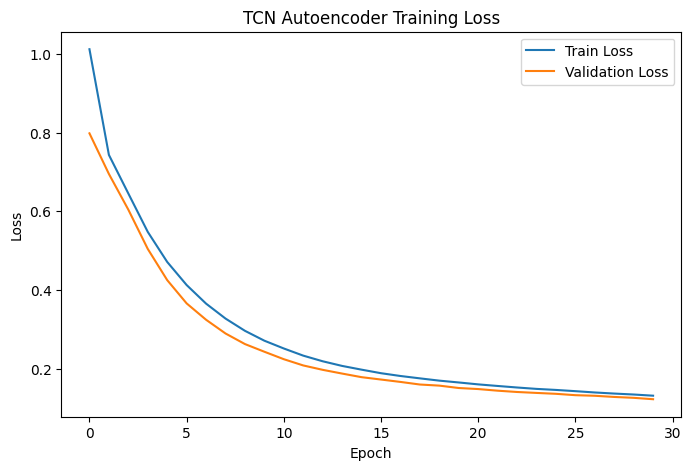

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("TCN Autoencoder Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [13]:
X_val_pred = model.predict(X_val)

print("Prediction shape:", X_val_pred.shape)

63/63 [==============================] - 1s 5ms/step
Prediction shape: (1997, 20, 41)


In [14]:
val_mse = np.mean(np.power(X_val - X_val_pred, 2), axis=(1, 2))

print("Validation MSE shape:", val_mse.shape)
print("First 10 reconstruction errors:", val_mse[:10])

Validation MSE shape: (1997,)
First 10 reconstruction errors: [0.15232328 0.09253621 0.11130036 0.09687433 0.14131423 0.12387893
 0.13212097 0.1181824  0.09213017 0.14042969]


In [15]:
threshold = val_mse.mean() + 3 * val_mse.std()
print("Threshold:", threshold)

Threshold: 0.17328280101747912


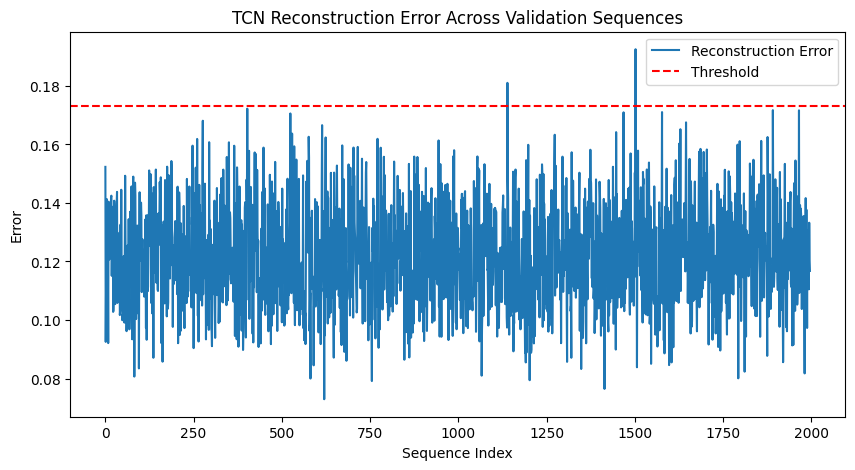

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(val_mse, label="Reconstruction Error")
plt.axhline(threshold, color="red", linestyle="--", label="Threshold")
plt.title("TCN Reconstruction Error Across Validation Sequences")
plt.xlabel("Sequence Index")
plt.ylabel("Error")
plt.legend()
plt.show()

In [17]:
anomaly_flags = val_mse > threshold

print("Potential anomalies found:", anomaly_flags.sum())
print("Total validation sequences:", len(anomaly_flags))
print("Percentage flagged:", (anomaly_flags.sum() / len(anomaly_flags)) * 100, "%")

Potential anomalies found: 2
Total validation sequences: 1997
Percentage flagged: 0.10015022533800699 %


In [18]:
model.save("tcn_autoencoder_tep.keras")
joblib.dump(scaler, "tcn_autoencoder_scaler.pkl")

print("TCN model and scaler saved successfully.")

TCN model and scaler saved successfully.


In [19]:
results_df = pd.DataFrame({
    "sequence_index": np.arange(len(val_mse)),
    "reconstruction_error": val_mse,
    "is_above_threshold": anomaly_flags
})

results_df.to_csv("tcn_autoencoder_results.csv", index=False)

results_df.head()

,sequence_index,reconstruction_error,is_above_threshold
0,0,0.152323,False
1,1,0.092536,False
2,2,0.111300,False
3,3,0.096874,False
4,4,0.141314,False


In [20]:
mean_error = val_mse.mean()
anomalies = (val_mse > threshold).sum()
total = len(val_mse)
rate = anomalies / total * 100

mean_error, anomalies, total, rate

(0.12204463197748655, 2, 1997, 0.10015022533800699)